In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import altair as alt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data1 = pd.read_csv('jordan_career.csv')
data2 = pd.read_csv('lebron_career.csv')
print(f"training data has : {data1.shape[0]} rows and {data1.shape[1]} columns")
print(f"testing data has : {data2.shape[0]} rows and {data2.shape[1]} columns")
data1 = data1.drop_duplicates()
print(f"Training data after removing duplicates: {data1.shape[0]} rows and {data1.shape[1]} columns")
data2 = data2.drop_duplicates()
print(f"Testing data after removing duplicates: {data2.shape[0]} rows and {data2.shape[1]} columns")

display(data1.head(3))
display(data2.head(3))

df_train, df_val = train_test_split(data1, test_size=0.2, random_state=200)
print(f"Split df_train vs df_val")
print(f"training data has : {df_train.shape[0]} rows and {df_train.shape[1]} columns")
print(f"validation data has : {df_val.shape[0]} rows and {df_val.shape[1]} columns")

df_train, df_val = train_test_split(data2, test_size=0.2, random_state=200)
print(f"Split df_train vs df_val")
print(f"training data has : {df_train.shape[0]} rows and {df_train.shape[1]} columns")
print(f"validation data has : {df_val.shape[0]} rows and {df_val.shape[1]} columns")

training data has : 1072 rows and 26 columns
testing data has : 1132 rows and 26 columns
Training data after removing duplicates: 1072 rows and 26 columns
Testing data after removing duplicates: 1132 rows and 26 columns


,game,date,age,team,opp,result,mp,fg,fga,fgp,...,orb,drb,trb,ast,stl,blk,tov,pts,game_score,minus_plus
0,1,1984-10-26,21-252,CHI,WSB,W (+16),40:00,5,16,0.313,...,1,5,6,7,2,4,5,16,12.5,NaN
1,2,1984-10-27,21-253,CHI,MIL,L (-2),34:00,8,13,0.615,...,3,2,5,5,2,1,3,21,19.4,NaN
2,3,1984-10-29,21-255,CHI,MIL,W (+6),34:00,13,24,0.542,...,2,2,4,5,6,2,3,37,32.9,NaN


,game,date,age,team,opp,result,mp,fg,fga,fgp,...,orb,drb,trb,ast,stl,blk,tov,pts,game_score,minus_plus
0,1,2003-10-29,18-303,CLE,SAC,L (-14),42:00,12,20,0.600,...,2,4,6,9,4,0,2,25,24.7,-9
1,2,2003-10-30,18-304,CLE,PHO,L (-9),41:00,8,17,0.471,...,2,10,12,8,1,0,7,21,14.7,-3
2,3,2003-11-01,18-306,CLE,POR,L (-19),39:00,3,12,0.250,...,0,4,4,6,2,0,2,8,5.0,-21


Split df_train vs df_val
training data has : 857 rows and 26 columns
validation data has : 215 rows and 26 columns
Split df_train vs df_val
training data has : 905 rows and 26 columns
validation data has : 227 rows and 26 columns


In [ ]:
data1.info()
data2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1072 entries, 0 to 1071
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   game        1072 non-null   int64  
 1   date        1072 non-null   object 
 2   age         1072 non-null   object 
 3   team        1072 non-null   object 
 4   opp         1072 non-null   object 
 5   result      1072 non-null   object 
 6   mp          1072 non-null   object 
 7   fg          1072 non-null   int64  
 8   fga         1072 non-null   int64  
 9   fgp         1072 non-null   float64
 10  three       1072 non-null   int64  
 11  threeatt    1072 non-null   int64  
 12  threep      742 non-null    float64
 13  ft          1072 non-null   int64  
 14  fta         1072 non-null   int64  
 15  ftp         1042 non-null   float64
 16  orb         1072 non-null   int64  
 17  drb         1072 non-null   int64  
 18  trb         1072 non-null   int64  
 19  ast         1072 non-null  

In [ ]:
data2['result'] = data2['result'].str[:1]
data2['date'] = pd.to_datetime(data2['date'])
data2["mp"] = data2["mp"].apply(lambda x: float(str(x).replace(":",".").split(",")[0].strip()))
data2["age"] = data2["age"].apply(lambda x: float(str(x).replace("-",".").split(",")[0].strip()))

In [ ]:
data

In [ ]:
data2.head()

,game,date,age,team,opp,result,mp,fg,fga,fgp,...,orb,drb,trb,ast,stl,blk,tov,pts,game_score,minus_plus
0,1,2003-10-29,18.303,CLE,SAC,L,42.0,12,20,0.600,...,2,4,6,9,4,0,2,25,24.7,-9
1,2,2003-10-30,18.304,CLE,PHO,L,41.0,8,17,0.471,...,2,10,12,8,1,0,7,21,14.7,-3
2,3,2003-11-01,18.306,CLE,POR,L,39.0,3,12,0.250,...,0,4,4,6,2,0,2,8,5.0,-21
3,4,2003-11-05,18.310,CLE,DEN,L,41.0,3,11,0.273,...,2,9,11,7,2,3,2,7,11.2,-3
4,5,2003-11-07,18.312,CLE,IND,L,44.0,8,18,0.444,...,0,5,5,3,0,0,7,23,9.0,-7


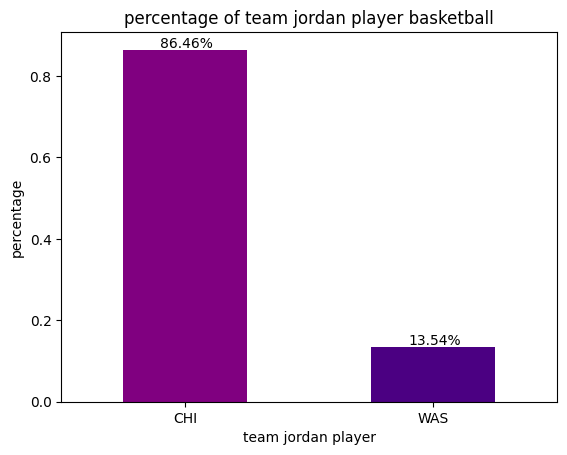

In [ ]:
team = df_train['team'].value_counts(normalize=True)
team.plot(kind='bar', color=['purple','indigo'])
plt.title('percentage of team jordan player basketball')
plt.xlabel('team jordan player')
plt.ylabel('percentage')
plt.xticks([0,1],['CHI','WAS'], rotation=0)
for i in range(len(team)):
  plt.text(i-0.1, team[i]+0.005, f"{team[i]*100:.2f}%")
plt.show()

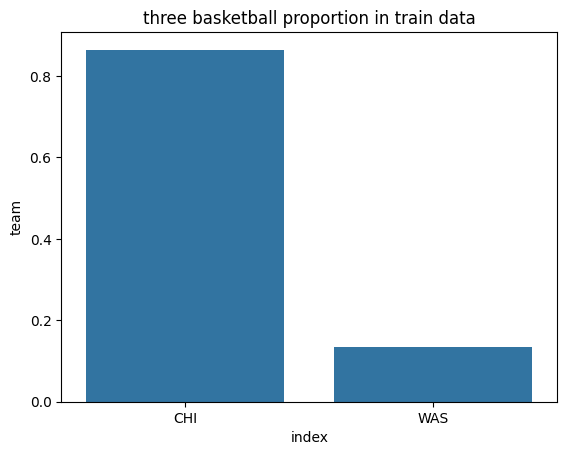

In [ ]:
team_count_normalize = df_train['team'].value_counts(normalize=True).reset_index()
sns.barplot(data=team_count_normalize, x='index', y='team')
plt.title('three basketball proportion in train data')
plt.show()

<ipython-input-32-22e162eccf1a>:2: UserWarning: 
The palette list has fewer values (2) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(data=df_train, x='fta', hue='three', kde=True, bins=30, palette=['purple','indigo'], alpha=0.4)


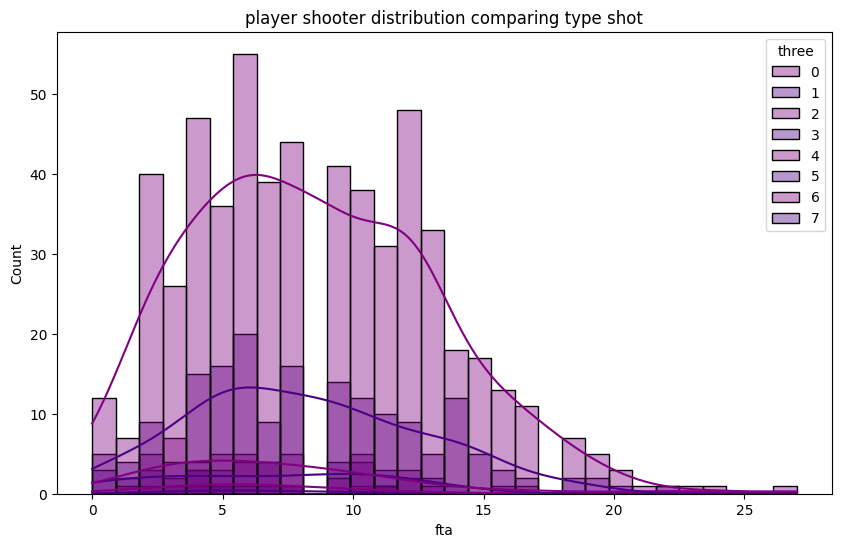

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_train, x='fta', hue='three', kde=True, bins=30, palette=['purple','indigo'], alpha=0.4)
plt.title('player shooter distribution comparing type shot')
plt.show()

In [ ]:
pts_hist = alt.Chart(df_train).mark_bar().encode(
    x=alt.X('pts', bin=alt.Bin(maxbins=30)),
    y='count()',
    color='team'
).properties(
    width=600,
    height=400,
    title='points of Distribution team CHI and WAS'
)
pts_hist

alt.Chart(...)

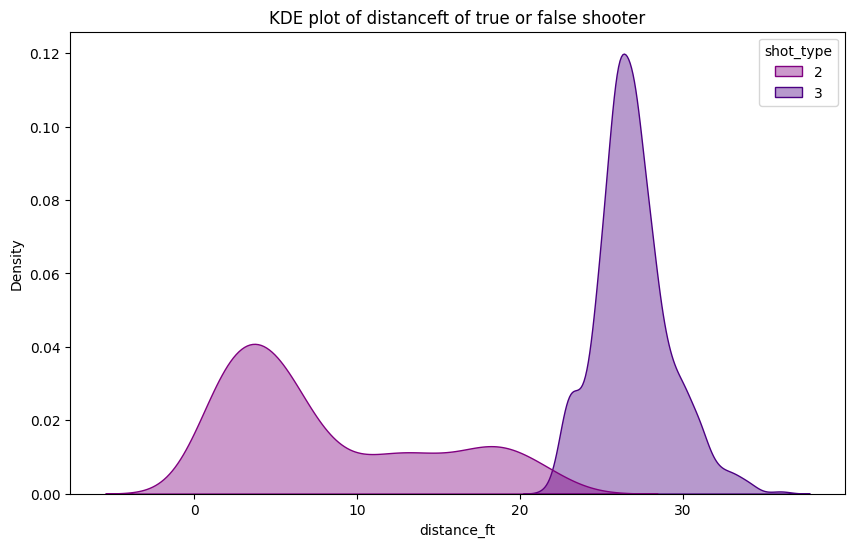

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_train, x='distance_ft', hue='team', fill=True, palette=['purple','indigo'], alpha=0.4)
plt.title('KDE plot of distanceft of true or false shooter')
plt.show()

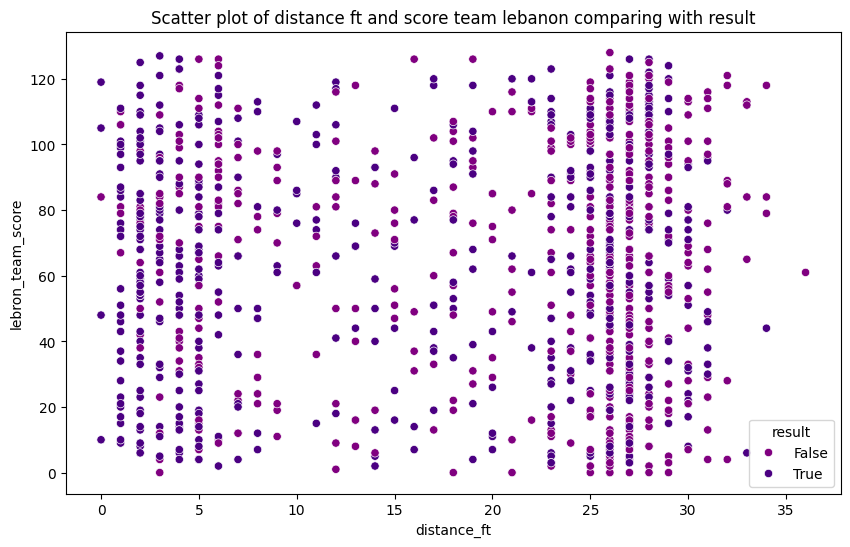

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='distance_ft', y='lebron_team_score', hue='result', palette=['purple','indigo'])
plt.title('Scatter plot of distance ft and score team lebanon comparing with result')
plt.show()

<ipython-input-90-7cf7a0c0c2af>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_train = df_train.drop(columns=['shot_type','result','top','left','team','qtr']).corr()


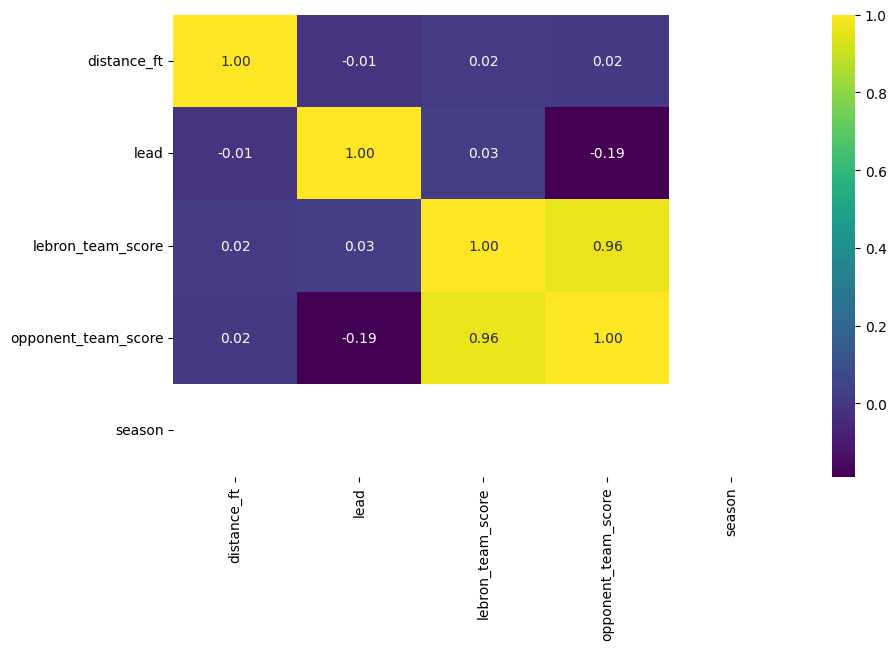

In [ ]:
corr_train = df_train.drop(columns=['shot_type','result','top','left','team','qtr']).corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_train, annot=True, cmap='viridis', fmt='.2f')
plt.title('')
plt.show()

In [ ]:
unused_columns=['qtr','time_remaining','team','season','color','date','opponent']
X_train = df_train.drop(columns=unused_columns)
y_train = df_train['qtr'].values.reshape(-1,1)
X_val = df_val.drop(columns=unused_columns)
y_val = df_val['qtr'].values.reshape(-1,1)

In [ ]:
distance_ft_pipeline = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', MinMaxScaler())])
lebron_team_score_pipeline = Pipeline([('scaler', StandardScaler())])
category_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder())
])
preprocessor = ColumnTransformer([
    ('distance_ft', distance_ft_pipeline,['distance_ft']),
    ('lebron_team_score', lebron_team_score_pipeline,['lebron_team_score']),
    ('category', category_pipeline,['result','shot_type'])
    ], remainder='passthrough'
)

In [ ]:
preprocessor.fit(X_train)
X_train_preprocessed = preprocessor.transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

In [ ]:
import pickle
with open ('preprocessor.pkl','wb') as file:
  pickle.dump(preprocessor, file)

In [ ]:
gnb = GaussianNB()
svm = SVC()

In [ ]:
gnb.fit(X_train_preprocessed, y_train.ravel())
svm.fit(X_train_preprocessed, y_train.ravel())
print("model fitted")

model fitted


In [ ]:
from time import perf_counter
gnb_start = perf_counter()
gnb.fit(X_train_preprocessed, y_train.ravel())
print(f"Naive bayes fitted in {perf_counter()-gnb_start:.4f}seconds")
svm_start = perf_counter()
svm.fit(X_train_preprocessed, y_train.ravel())
print(f"Support Vector Machine fitted in {perf_counter()-gnb_start:.4f}seconds")
print("Model fitted")

Naive bayes fitted in 0.0059seconds
Support Vector Machine fitted in 0.0715seconds
Model fitted


In [ ]:
gnb_val_pred = gnb.predict(X_val_preprocessed)
svm_val_pred = svm.predict(X_val_preprocessed)
print("prediction done")

prediction done


In [ ]:
gnb_accuracy = accuracy_score(y_val,gnb_val_pred)
print(f"Naive bayes Accuracy {gnb_accuracy:.4f}")
svm_accuracy = accuracy_score(y_val,svm_val_pred)
print(f"Support Vector Machine Accuracy {svm_accuracy:.4f}")

Naive bayes Accuracy 0.8606
Support Vector Machine Accuracy 0.8328


In [ ]:
gnb_report = classification_report(y_val,gnb_val_pred)
print("Naive Bayes")
print(gnb_report)
svm_report = classification_report(y_val,svm_val_pred)
print("Support Vector Machine")
print(svm_report)

Naive Bayes
              precision    recall  f1-score   support

      1st OT       0.00      0.00      0.00         2
     1st Qtr       0.96      0.95      0.95        75
     2nd Qtr       0.79      0.82      0.80        60
     3rd Qtr       0.81      0.81      0.81        79
     4th Qtr       0.89      0.89      0.89        71

    accuracy                           0.86       287
   macro avg       0.69      0.69      0.69       287
weighted avg       0.86      0.86      0.86       287

Support Vector Machine
              precision    recall  f1-score   support

      1st OT       0.00      0.00      0.00         2
     1st Qtr       0.96      0.91      0.93        75
     2nd Qtr       0.75      0.78      0.76        60
     3rd Qtr       0.78      0.76      0.77        79
     4th Qtr       0.84      0.90      0.87        71

    accuracy                           0.83       287
   macro avg       0.67      0.67      0.67       287
weighted avg       0.83      0.83      0.8

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
